# Caderno 1 - Estatísticas da base de dados e análise da anotação humana

## 1. Arquivos de entrada

In [1]:
ARQUIVO_DOCS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/docs.csv'
ARQUIVO_QUERIES = './dados/outputs/0 - qrel - docs - query - raw_human_eval/query.csv'
ARQUIVO_QRELS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/qrel.csv'
ARQUIVO_HUMAN_EVALS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/raw_human_eval.csv'

## 2. Dataframes

In [2]:
import pandas as pd

df_docs = pd.read_csv(ARQUIVO_DOCS)
df_queries = pd.read_csv(ARQUIVO_QUERIES)
df_qrels = pd.read_csv(ARQUIVO_QRELS)
df_human_evals = pd.read_csv(ARQUIVO_HUMAN_EVALS)

df_docs['TEXTONORMA'] = df_docs['TEXTONORMA'].fillna('')
df_docs['TEXTOANEXO'] = df_docs['TEXTOANEXO'].fillna('')

In [3]:
print(f"Total de documentos: {len(df_docs)}")
print(f"Total de avaliações no qrels: {len(df_qrels)}")
print(f"Total de avaliações individuais: {len(df_human_evals)}")

Total de documentos: 14469
Total de avaliações no qrels: 812
Total de avaliações individuais: 3048


## 3. Análise das anotações humanas

### 3.1. Distribuição do label por anotador


=== Label distribution (counts) per annotator ===
AVALIACAO             0    1    2  Total
USUARIO_AVALIADOR                       
A_1                 536   66  203    805
A_2                 477   80  156    713
A_3                 461  137  207    805
A_4                 451  166  108    725
Total              1925  449  674   3048

=== Label distribution (%) per annotator ===
AVALIACAO             0     1     2
USUARIO_AVALIADOR                  
A_1                66.6   8.2  25.2
A_2                66.9  11.2  21.9
A_3                57.3  17.0  25.7
A_4                62.2  22.9  14.9


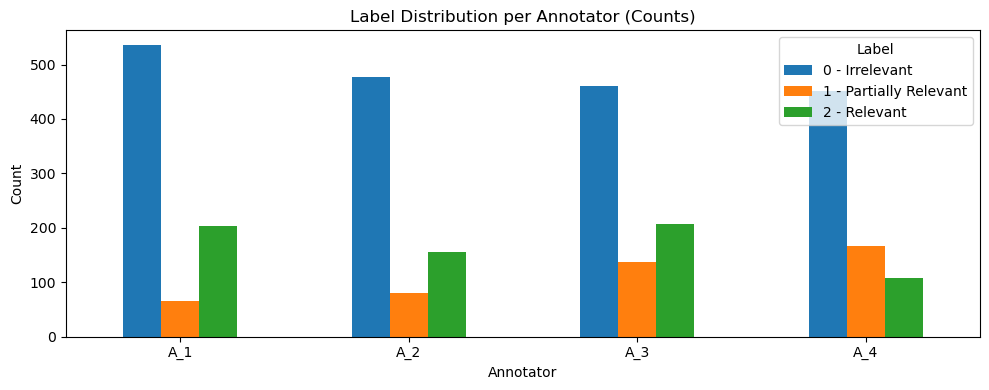

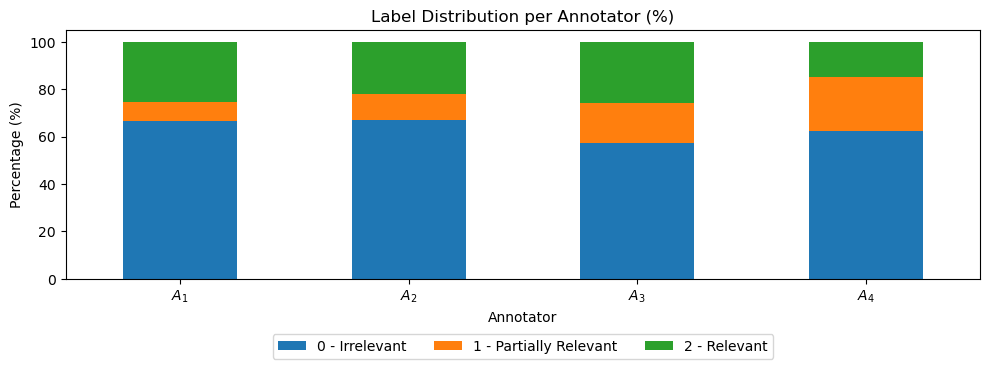

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LEVEL 1 — Individual annotator behavior
# Fixed annotator order: A_1, A_2, A_3, A_4
# ============================================================

df = df_human_evals.copy()

# Fixed annotator order
eval_order = ["A_1", "A_2", "A_3", "A_4"]

# ============================================================
# 1.1 Tables: label distribution per annotator
# ============================================================

# Absolute counts of labels (0/1/2)
dist_counts = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

# ---- Add row totals (Total per annotator)
dist_counts["Total"] = dist_counts.sum(axis=1)

# ---- Add column totals (Total per label + grand total)
column_totals = dist_counts.sum(axis=0)
dist_counts.loc["Total"] = column_totals

# Percentages (computed BEFORE adding totals row)
dist_pct = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

dist_pct = dist_pct.div(dist_pct.sum(axis=1), axis=0)

# ============================================================
# PRINT TABLES
# ============================================================

print("\n=== Label distribution (counts) per annotator ===")
print(dist_counts)

print("\n=== Label distribution (%) per annotator ===")
print((dist_pct * 100).round(1))

# ============================================================
# PLOTS (unchanged)
# ============================================================

# Remove the totals row for plotting
plot_counts = dist_counts.loc[eval_order, [0, 1, 2]]
plot_pct = dist_pct.loc[eval_order, [0, 1, 2]]

label_map = {
    0: "0 - Irrelevant",
    1: "1 - Partially Relevant",
    2: "2 - Relevant"
}

# ---------------------------
# 1) Grouped bar chart (counts)
# ---------------------------
ax = plot_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Label Distribution per Annotator (Counts)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Count")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]
ax.legend(handles, labels, title="Label", ncol=1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ---------------------------
# 2) Stacked bar chart (percentages)
# ---------------------------
ax = (plot_pct * 100).plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_title("Label Distribution per Annotator (%)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Percentage (%)")

handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]
ax.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3
)
# Converte para subscrito
ax.set_xticklabels([f"${anotador}$" for anotador in eval_order])
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig("label_distribution_percentage.png", dpi=300, bbox_inches="tight")
plt.show()



### 3.2. Total de consenso e desacordos entre os avaliadores

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# DISAGREEMENT STUDY (pair-level), considering 1..4 annotators per (query, doc)
#
# Buckets per (QUERY_KEY, DOC_KEY):
#   - Total consensus: range == 0
#       split by label: 0 / 1 / 2
#   - Weak disagreement: range == 1
#       split by observed pair: 0-1 or 1-2 (determined by min label)
#   - Strong disagreement: range == 2  (0 vs 2 present)
#
# IMPORTANT:
#   - Works even if only 1/2/3 annotators rated a pair (skip NaNs).
#   - A pair with only 1 annotator is ALWAYS "consensus" (trivially),
#     and counted under consensus label = that single label.
#
# Outputs:
#   1) Summary table with totals (counts + %)
#   2) Summary table broken down by n_raters (1,2,3,4), with totals
# ============================================================

annotators = ["A_1", "A_2", "A_3", "A_4"]

# Wide format: rows=(QUERY_KEY, DOC_KEY), cols=annotators
wide = df.pivot_table(
    index=["QUERY_KEY", "DOC_KEY"],
    columns="USUARIO_AVALIADOR",
    values="AVALIACAO",
    aggfunc="first"
).reindex(columns=annotators)

# How many annotators rated each pair
n_raters = wide.notna().sum(axis=1)

# Min / max label per pair (ignoring NaNs)
row_min = wide.min(axis=1, skipna=True)
row_max = wide.max(axis=1, skipna=True)
row_range = row_max - row_min

# ----------------------------
# Assign each pair to a bucket
# ----------------------------
bucket = pd.Series(index=wide.index, dtype="object")

# Total consensus: all available labels are equal (range=0)
bucket[row_range == 0] = "Consensus"

# Weak disagreement: range=1, split by whether it's {0,1} or {1,2}
bucket[(row_range == 1) & (row_min == 0)] = "Weak (0-1)"
bucket[(row_range == 1) & (row_min == 1)] = "Weak (1-2)"

# Strong disagreement: range=2 (contains 0 and 2)
bucket[row_range == 2] = "Strong (0-2)"

# For completeness (shouldn't happen with labels in {0,1,2}):
bucket = bucket.fillna("Other")

# For consensus, capture which label the consensus was on (0/1/2)
consensus_label = pd.Series(index=wide.index, dtype="float")
consensus_label[row_range == 0] = row_min[row_range == 0]  # min==max==label

# ============================================================
# 1) Main summary table (counts + %), with totals
# ============================================================

# Count by bucket
bucket_counts = bucket.value_counts().reindex(
    ["Consensus", "Weak (0-1)", "Weak (1-2)", "Strong (0-2)", "Other"],
    fill_value=0
)

# Consensus split by label (0/1/2)
cons_label_counts = (
    consensus_label.dropna()
    .astype(int)
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
)

# Build a clean summary table
summary_rows = [
    ("Consensus (total)", bucket_counts["Consensus"]),
    ("  Consensus on label 0", cons_label_counts[0]),
    ("  Consensus on label 1", cons_label_counts[1]),
    ("  Consensus on label 2", cons_label_counts[2]),
    ("Weak disagreement (total)", bucket_counts["Weak (0-1)"] + bucket_counts["Weak (1-2)"]),
    ("  Weak disagreement 0-1", bucket_counts["Weak (0-1)"]),
    ("  Weak disagreement 1-2", bucket_counts["Weak (1-2)"]),
    ("Strong disagreement (0-2)", bucket_counts["Strong (0-2)"]),
    ("Other", bucket_counts["Other"]),
]

summary = pd.DataFrame(summary_rows, columns=["Category", "Count"])

# Add percentages (over ALL pairs, regardless of n_raters)
N_pairs = len(wide)
summary["Percent"] = (summary["Count"] / N_pairs) * 100

# Add totals row
summary.loc[len(summary)] = ["Total pairs", N_pairs, 100.0]

print("\n=== Pair-level agreement / disagreement summary (ALL pairs) ===")
print(summary.assign(Percent=summary["Percent"].round(2)))

# ============================================================
# 2) Breakdown by number of annotators (n_raters) + totals
# ============================================================

tmp = pd.DataFrame({
    "n_raters": n_raters,
    "bucket": bucket
})

# Counts per n_raters and bucket
by_n = (
    tmp.groupby(["n_raters", "bucket"])
       .size()
       .unstack(fill_value=0)
       .reindex(columns=["Consensus", "Weak (0-1)", "Weak (1-2)", "Strong (0-2)", "Other"], fill_value=0)
       .reindex(index=[1,2,3,4], fill_value=0)
)

# Add row totals (per n_raters)
by_n["Total"] = by_n.sum(axis=1)

# Add column totals (overall totals per bucket + grand total)
col_totals = by_n.sum(axis=0)
by_n.loc["Total"] = col_totals

print("\n=== Breakdown by number of annotators (n_raters) ===")
print(by_n)

# ============================================================
# (Optional) If you want percentages by n_raters as well:
# ============================================================
by_n_pct = by_n.loc[[1,2,3,4], ["Consensus", "Weak (0-1)", "Weak (1-2)", "Strong (0-2)", "Other"]].copy()
by_n_pct = by_n_pct.div(by_n_pct.sum(axis=1), axis=0) * 100
by_n_pct["Total"] = 100.0  # by definition

print("\n=== Breakdown by n_raters (row-wise %) ===")
print(by_n_pct.round(2))



=== Pair-level agreement / disagreement summary (ALL pairs) ===
                    Category  Count  Percent
0          Consensus (total)    437    53.82
1       Consensus on label 0    360    44.33
2       Consensus on label 1     11     1.35
3       Consensus on label 2     66     8.13
4  Weak disagreement (total)    225    27.71
5      Weak disagreement 0-1    135    16.63
6      Weak disagreement 1-2     90    11.08
7  Strong disagreement (0-2)    150    18.47
8                      Other      0     0.00
9                Total pairs    812   100.00

=== Breakdown by number of annotators (n_raters) ===
bucket    Consensus  Weak (0-1)  Weak (1-2)  Strong (0-2)  Other  Total
n_raters                                                               
1                 8           0           0             0      0      8
2                32           8           2             5      0     47
3                32          19           9            22      0     82
4               365       

### 3.3. Kappa de Cohen

In [6]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import pandas as pd
import numpy as np

annotators = ["A_1","A_2","A_3","A_4"]

# Criar matriz vazia
kappa_matrix = pd.DataFrame(
    np.nan,
    index=annotators,
    columns=annotators
)

# Preencher diagonal com 1 (concordância perfeita consigo mesmo)
for a in annotators:
    kappa_matrix.loc[a, a] = 1.0

# Calcular kappas par-a-par
for a1, a2 in combinations(annotators, 2):
    
    sub = wide[[a1, a2]].dropna()
    
    kappa = cohen_kappa_score(
        sub[a1],
        sub[a2],
        weights="quadratic"
    )
    
    kappa_matrix.loc[a1, a2] = kappa
    kappa_matrix.loc[a2, a1] = kappa  # matriz simétrica

print("\n=== Pairwise Weighted Cohen's Kappa (quadratic) ===")
print(kappa_matrix.round(4))



=== Pairwise Weighted Cohen's Kappa (quadratic) ===
        A_1     A_2     A_3     A_4
A_1  1.0000  0.7301  0.5466  0.6688
A_2  0.7301  1.0000  0.6055  0.6951
A_3  0.5466  0.6055  1.0000  0.5809
A_4  0.6688  0.6951  0.5809  1.0000


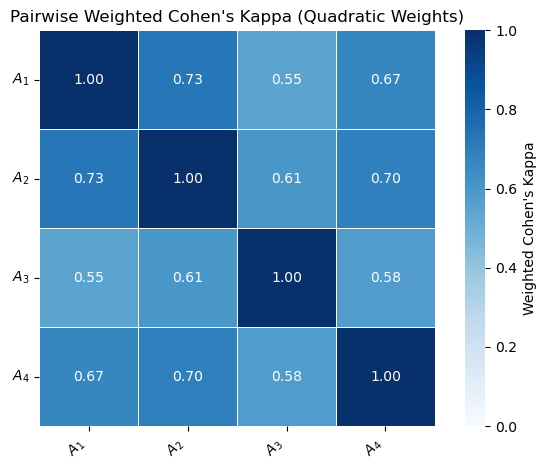

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que os valores são float
kappa_plot = kappa_matrix.astype(float)

# Converter labels para subscrito
kappa_plot.index = [f"${x}$" for x in kappa_plot.index]
kappa_plot.columns = [f"${x}$" for x in kappa_plot.columns]

# Cria figura maior (nomes longos precisam de espaço)
#plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    kappa_plot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Weighted Cohen's Kappa"}
)

plt.title("Pairwise Weighted Cohen's Kappa (Quadratic Weights)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig("cohen_kappa_human.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.4. Alpha de Krippendorff

In [8]:
import numpy as np
import krippendorff

annotators = ["A_1", "A_2", "A_3", "A_4"]

# krippendorff expects reliability_data as (raters x items)
data = wide[annotators].to_numpy().T

alpha_ordinal = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement="ordinal"
)

print("Krippendorff's alpha (ordinal):", round(alpha_ordinal, 4))

Krippendorff's alpha (ordinal): 0.6188


### 3.5. Cálculo do percentual de documentos com desacordo forte (tem anotação com 0 e em 2) por query:

In [9]:
# ------------------------------------------------------------
# Recalcular o necessário (apenas o mínimo)
# ------------------------------------------------------------

annotators = ["A_1","A_2","A_3","A_4"]

# Número de avaliadores por par
n_raters = wide[annotators].notna().sum(axis=1)

# Min / max / range por par
row_min = wide[annotators].min(axis=1, skipna=True)
row_max = wide[annotators].max(axis=1, skipna=True)
row_range = row_max - row_min

# Strong disagreement: contém 0 e 2 (range == 2)
strong_mask = (row_range == 2)

# QUERY_KEY por linha
query_index = wide.index.get_level_values("QUERY_KEY")

# ------------------------------------------------------------
# 1) Número de documentos avaliados por query
# ------------------------------------------------------------
docs_per_query = (
    pd.Series(query_index)
      .value_counts()
      .rename("n_documents")
)

# ------------------------------------------------------------
# 2) Total de avaliações por query
# ------------------------------------------------------------
evaluations_per_query = (
    pd.DataFrame({
        "QUERY_KEY": query_index,
        "n_raters": n_raters.values
    })
    .groupby("QUERY_KEY")["n_raters"]
    .sum()
    .rename("n_evaluations")
)

# ------------------------------------------------------------
# 3) Percentual de strong disagreement por query
# ------------------------------------------------------------
strong_pct_by_query = (
    pd.DataFrame({
        "QUERY_KEY": query_index,
        "strong": strong_mask.values
    })
    .groupby("QUERY_KEY")["strong"]
    .mean()
    .mul(100)
    .rename("strong_disagreement_pct")
)

# ------------------------------------------------------------
# 4) Consolidar tabela final
# ------------------------------------------------------------
query_summary = pd.concat(
    [strong_pct_by_query, docs_per_query, evaluations_per_query],
    axis=1
).sort_values("strong_disagreement_pct", ascending=False)

# Linha total geral
query_summary.loc["Total"] = [
    strong_mask.mean() * 100,
    len(wide),
    n_raters.sum()
]

print(query_summary.round(2))


           strong_disagreement_pct  n_documents  n_evaluations
QUERY_KEY                                                     
17                           50.00         10.0           40.0
8                            47.37         19.0           75.0
10                           45.00         20.0           80.0
46                           43.75         16.0           64.0
32                           42.11         19.0           69.0
9                            40.00         20.0           77.0
49                           38.89         18.0           45.0
29                           36.84         19.0           59.0
21                           36.84         19.0           76.0
16                           35.29         17.0           67.0
7                            30.00         20.0           80.0
31                           29.41         17.0           65.0
24                           28.57         14.0           43.0
35                           28.57          7.0        